# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Generative AI 코드 과제 🐻‍❄️


이번 과제에서는 VAE 모델과 DCGAN 모델을 직접 구현 및 학습하여 이미지를 생성해보고, 그 결과를 비교해보겠습니다.

- **VAE(Variational AutoEncoder)**: 입력 데이터를 저차원의 잠재 공간(latent space)으로 압축한 뒤, 이 공간의 확률 분포를 기반으로 다시 원본 데이터를 복원 및 생성하도록 하는 모델

- **GAN(Generative Adversarial Network)**: 생성자(Generator)와 판별자(Discriminator)라는 두 개의 네트워크가 서로 경쟁하며 학습하는 모델
  * Generator: Random noise를 입력받아 진짜(Real) 같은 가짜(Fake) 데이터를 생성 (=위조지폐범)
  * Discriminator: 입력받은 데이터가 Real인지 Fake인지 구분 (=경찰)

- **DCGAN (Deep Convolutional GAN)**: 기존 GAN은 단순한 MLP(Multi-Layer Perceptron) 구조인 반면, DCGAN은 이를 Convolutional 구조로 확장하여 이미지의 생성 성능을 향상시킨 모델

### **모듈 임포트 및 디바이스 설정**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### **데이터셋 준비 (MNIST dataset)**

In [3]:
batch_size = 128
epochs = 30

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 61.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.48MB/s]


## **VAE(Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원

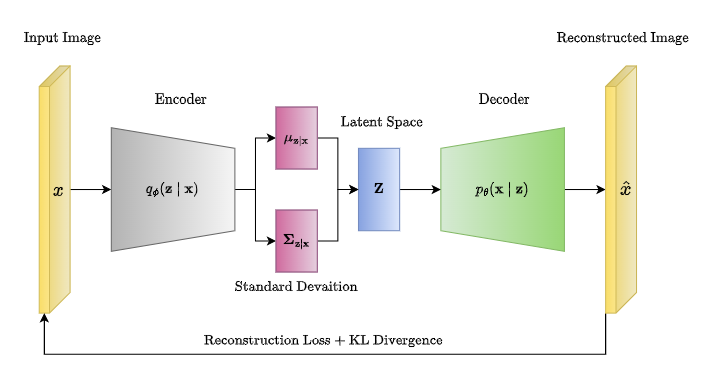

참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [4]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20, data_type="binary"):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

        self.data_type = data_type

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mean = self.fc21(h1) # 🤔 빈칸을 채워주세요
        log_var = self.fc21(h1) # 🤔 빈칸을 채워주세요
        return mean, log_var

    @staticmethod
    def reparameterize(mean, log_var):

        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)

        z = mean + std * eps
        return z

    def decode(self, z):

        h3 = F.relu(self.fc3(z))

        logits = self.fc4(h3)
        probs = torch.sigmoid(logits)

        return probs

    def forward(self, x):

        x = x.view(-1, 784)

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

### **VAE loss (ELBO)**
* Reconsturction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정

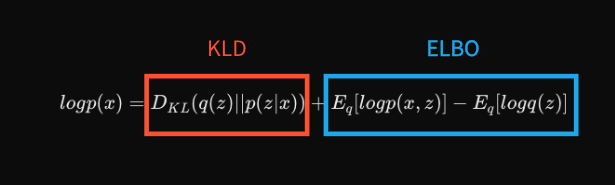


In [5]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD # 🤔 빈칸을 채워주세요

    return total_loss

## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.

1. 통계적 해석

우리의 진짜 목표는 이미지의 생성이므로, 통계적으로 해석하면 그것은 데이터 $x$가 주어졌을 때 잠재 변수 $z$의 분포인 사후 분포 $p(z|x)$를 아는 것이다. 하지만 실제 $p(z|x)$는 계산이 불가능(Intractable)할 정도로 복잡하다고 본다. 그래서 우리는 다루기 쉬운 분포 $q_\phi(z|x)$(인코더)를 만들어 진짜 사후 분포와 최대한 비슷하게 만들기로 한다.

이때 "두 확률 분포가 얼마나 닮았는가"를 측정하는 척도가 바로 KL Divergence입니다. 수식으로 보면 다음과 같다:$$\log p(x) = \text{ELBO} + D_{KL}(q_\phi(z|x) || p(z|x))$$

우리는 로그 Likelihood $\log p(x)$를 최대화하고 싶은데, 오른쪽의 KLD 항은 계산할 수 없다. 대신 KLD는 항상 0보다 크거나 같다는 성질을 이용해(log), ELBO를 최대화함으로써 간접적으로 KLD를 최소화하고 사후 분포에 근사하게 된다.

2. 규제의 관점

KLD 항은 인코더가 만든 분포 $q(z|x)$가 사전에 설정한 Prior(우선 순위 분포, 보통 표준정규분포 $N(0, 1)$)와 너무 멀어지지 않도록 붙잡아두는 규제(Regularizer) 역할을 한다. 이것이 VAE의 가장 기본적인 아이디어 이기도 하다.

KLD 항이 없다면 인코더는 복원(Reconstruction) 점수를 높이기 위해 각 데이터를 latent space의 아주 좁은 특정 점에만 매핑하려고 하게 된다.(Overfitting).

반면 KLD 항이 있는 경우에 인코더는 최대한 $N(0, 1)$ 와 비슷하게 생성하려는 압력을 받게 된다. 이 과정에서 비슷한 특징을 가진 데이터들이 latent space 상에서 가깝게 모이게 되고, 동시에 빈틈없이 채워져서 이미지가 생성된다.

3. 생성의 관점

VAE는 새로운 이미지를 '생성'하는 것이 목적이다. 이미지를 생성하려면 잠재 공간의 어떤 지점($z$)을 우리가 직접 골라야 하는데, 만약 latent space가 정규분포를 따르지 않고 엉망으로 흩어져 있다면 어디서 숫자를 뽑아야 할지 알 수 없다.

그런데 KLD 항 덕분에 latent space가 표준정규분포 $N(0, 1)$의 형태를 띠게 되므로, 표준정규분포에서 무작위로 숫자를 뽑아(Sampling) 디코더에 넣기만 하면 그럴듯한 새로운 이미지를 얻을 수 있게 된다.


In [6]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):


    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x,_ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x,recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():

        for x,_ in val_loader:

            x = x.to(device)

            recon, mu, logvar = vae(x)

            loss = elbo_loss(x, recon, mu, logvar)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"[VAE] Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

[VAE] Epoch 1/30 | Train Loss: 182.3648 | Val Loss: 154.2005
[VAE] Epoch 2/30 | Train Loss: 148.5207 | Val Loss: 145.3896
[VAE] Epoch 3/30 | Train Loss: 142.8303 | Val Loss: 141.4051
[VAE] Epoch 4/30 | Train Loss: 139.5960 | Val Loss: 138.9942
[VAE] Epoch 5/30 | Train Loss: 137.9021 | Val Loss: 137.6375
[VAE] Epoch 6/30 | Train Loss: 136.4986 | Val Loss: 136.3423
[VAE] Epoch 7/30 | Train Loss: 135.5073 | Val Loss: 135.4568
[VAE] Epoch 8/30 | Train Loss: 134.6805 | Val Loss: 135.1050
[VAE] Epoch 9/30 | Train Loss: 134.0844 | Val Loss: 134.3705
[VAE] Epoch 10/30 | Train Loss: 133.5582 | Val Loss: 133.9385
[VAE] Epoch 11/30 | Train Loss: 133.2104 | Val Loss: 133.5270
[VAE] Epoch 12/30 | Train Loss: 132.6732 | Val Loss: 133.2973
[VAE] Epoch 13/30 | Train Loss: 132.3276 | Val Loss: 133.0121
[VAE] Epoch 14/30 | Train Loss: 131.9108 | Val Loss: 132.6368
[VAE] Epoch 15/30 | Train Loss: 131.7093 | Val Loss: 132.2197
[VAE] Epoch 16/30 | Train Loss: 131.4456 | Val Loss: 132.4801
[VAE] Epoch 17/30

**VAE sampling 시각화**

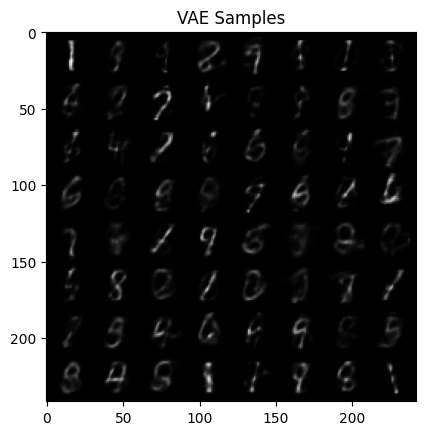

In [7]:
with torch.no_grad():

    z = torch.randn(64,20).to(device)

    samples = vae.decode(z).view(-1,1,28,28)

    grid = make_grid(samples,8)

plt.imshow(grid.permute(1,2,0).cpu())
plt.title("VAE Samples")
plt.show()

## **DCGAN(Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - LeakyReLU: 음수 영역에 작은 양수 기울기를 부여하여 Gradient Vanishing 문제를 해결
  - Activation: 마지막 layer에 sigmoid를 사용하여 real(1)/fake(0) 사이의 확률 값을 출력


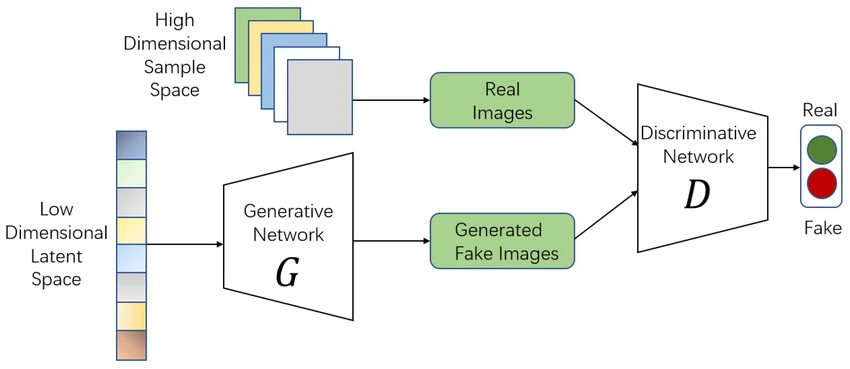


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [9]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [10]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size,256,7,1,0,bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256,128,4,2,1,bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128,64,4,2,1,bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64,1,3,1,1,bias=False)

    def forward(self,x):

        x = F.relu(self.bn1(self.tconv1(x)))
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))

        x = torch.tanh(self.tconv4(x))

        return x

In [11]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,out_channels=64,kernel_size=4,stride=2,padding=1,bias=False)

        self.conv2 = nn.Conv2d(64,128,4,2,1,bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128,256,4,2,1,bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256,1,3,1,0,bias=False)

    def forward(self,x):

        x = F.leaky_relu(self.conv1(x),0.2,True)

        x = F.leaky_relu(self.bn2(self.conv2(x)),0.2,True)

        x = F.leaky_relu(self.bn3(self.conv3(x)),0.2,True)

        x = torch.sigmoid(self.conv4(x))

        return x.view(-1)

In [12]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(),0.0002,betas=(0.5,0.999))
optD = optim.Adam(D.parameters(),0.0002,betas=(0.5,0.999))

In [13]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x,_ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)


        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0),latent_size,1,1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()


        # ========== Train Generator ==========

        lossG = criterion(D(fake_img),real) # 🤔 빈칸을 채워주세요

        optG.zero_grad()
        lossG.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += lossG.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"[DCGAN] Epoch {epoch+1}/{epochs} | Train D Loss {train_lossD:.4f} | Train G Loss {train_lossG:.4f}")

[DCGAN] Epoch 1/30 | Train D Loss 0.8232 | Train G Loss 1.6402
[DCGAN] Epoch 2/30 | Train D Loss 0.8976 | Train G Loss 1.4516
[DCGAN] Epoch 3/30 | Train D Loss 0.9599 | Train G Loss 1.3850
[DCGAN] Epoch 4/30 | Train D Loss 0.9973 | Train G Loss 1.3429
[DCGAN] Epoch 5/30 | Train D Loss 0.9837 | Train G Loss 1.3616
[DCGAN] Epoch 6/30 | Train D Loss 0.9703 | Train G Loss 1.4060
[DCGAN] Epoch 7/30 | Train D Loss 0.9729 | Train G Loss 1.4086
[DCGAN] Epoch 8/30 | Train D Loss 0.9537 | Train G Loss 1.4421
[DCGAN] Epoch 9/30 | Train D Loss 0.9739 | Train G Loss 1.4445
[DCGAN] Epoch 10/30 | Train D Loss 0.9610 | Train G Loss 1.4602
[DCGAN] Epoch 11/30 | Train D Loss 0.9295 | Train G Loss 1.5084
[DCGAN] Epoch 12/30 | Train D Loss 0.9353 | Train G Loss 1.5293
[DCGAN] Epoch 13/30 | Train D Loss 0.9070 | Train G Loss 1.5549
[DCGAN] Epoch 14/30 | Train D Loss 0.9086 | Train G Loss 1.5700
[DCGAN] Epoch 15/30 | Train D Loss 0.8878 | Train G Loss 1.6240
[DCGAN] Epoch 16/30 | Train D Loss 0.8832 | Train

**DCGAN Sampling 시각화**

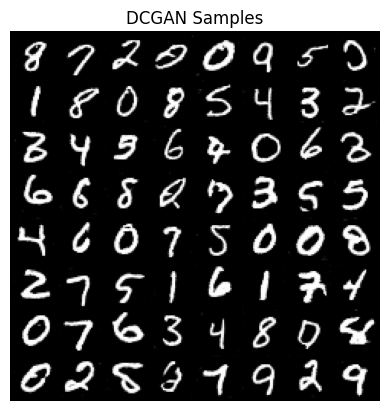

In [14]:
G.eval()

with torch.no_grad():

    z = torch.randn(64,latent_size,1,1).to(device)

    samples = G(z)

grid = make_grid(samples,8,normalize=True)

plt.imshow(grid.permute(1,2,0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()

## **🙋 [GAN] Question 2-1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

1. VAE

VAE는 데이터의 확률 분포 $p(x)$를 직접 모델링하는 것이 특징이다.

학습 방식 (ELBO 최대화): VAE는 입력 데이터를 잠재 공간(Latent Space)으로 압축했다가 다시 복원하는 과정에서 Reconstruction Loss(MSE 또는 BCE)를 사용한다.

흐릿한 이유: 통계적으로 MSE(Mean Squared Error) 손실 함수는 데이터의'평균(Mean)'을 찾는 경향이 있기 때문이다. 예를 들어, 숫자 '1'이 왼쪽으로 1픽셀 치우친 이미지와 오른쪽으로 1픽셀 치우친 이미지가 있다면, VAE는 두 경우의 오차를 최소화하기 위해 그 중간인 '가운데가 뭉툭하고 흐릿한 1'을 선택하게 된다.

또한 잠재 변수 $z$를 표준정규분포 $N(0, I)$에 강제로 맞추려는 KL-Divergence 항이 일종의 규제(Regularization) 역할을 하여, 데이터의 세밀한 특징보다는 전체적인 '형태'에 집중해서 생성하게 만든다.

2. GAN

GAN은 분포를 직접 계산하지 않고, 샘플링을 통해 판별자를 속이는 식의 경쟁을 통해 학습한다.

학습 방식 (게임 이론, Adverserial game): 생성자(G)와 판별자(D)가 서로 속고 속이는 게임을 한다. 생성자의 목적 함수는 판별자가 진짜라고 믿게 만드는 것입니다.

선명한 이유: 판별자(D)는 아주 작은 위조 흔적(흐릿한 픽셀, 부자연스러운 경계)만 보여도 "가짜"라고 판정해 버린다. 생성자(G)는 생존을 위해 판별자가 잡아낼 수 없는 선명한 경계선(High-frequency details)을 만들어내야만 한다.

통계적으로 GAN은 Jensen-Shannon Divergence를 최소화하는 방향으로 학습되는데, 이는 데이터 분포의 '평균'이 아니라 실제 데이터가 존재할 법한 '매니폴드(Manifold) 상의 점'을 정확히 찍어내도록 한다.

3. DCGAN

단순히 GAN의 방식이라서 선명한 것이 아니라, DC(Deep Convolutional) 구조가 큰 역할을 한다고 보는 것이 맞다.

Spatial Hierarchy: 기존 MLP(다층 퍼셉트론) 기반 VAE는 픽셀 간의 위치 관계를 무시하고 일자로 펴서 학습하지만, DCGAN은 Convolution 레이어를 통해 이미지의 국소적인 특징(선, 곡선, 질감)을 계층적으로 학습한다.

Feature Map: 낮은 층에서는 점과 선을, 높은 층에서는 숫자의 전체적인 형상을 학습함으로써 이미지의 해상도와 디테일을 동시에 높이는 식으로 학습한다.

## **🙋 [GAN] Question 2-2**
GAN 학습 과정에서 Generator의 Loss가 증가하는 것이 반드시 모델 성능 악화를 의미하지 않는 이유는 무엇인지 설명해주세요.

1. GAN의 원리:

GAN은 고정된 정답(Label) 기반의 경쟁이 아니다.

생성자(G)가 성능이 좋아져서 아주 정교한 이미지를 만들기 시작했다고 가정하자. 이때 판별자(D)가 더 빠른 속도로 학습되어 생성자가 만든 미세한 결점을 찾아내기 시작하면 G의 Loss는 수치상으로 상승하게 됩니다. 즉, G의 Loss 상승은 G가 못해져서가 아니라 D의 성능이 좋아져서 발생하는 상대적인 수치가 된다.

2. 게임 이론과 내쉬 평형

GAN의 목적 함수는 한쪽의 이득이 곧 상대의 손실이 되는 구조이다. 완벽한 GAN 학습 상태(내쉬 평형)에 도달하면, 판별자는 진짜와 가짜를 전혀 구별하지 못해 확률 $0.5$를 갖게 된다.

이때의 Loss는 ($BCELoss$ 수식에 $0.5$를 대입) $-\log(0.5) \approx 0.693$이라는 값에 수렴하게 된다.

만약 G Loss가 $0.1$처럼 너무 낮다면, 그건 G가 완벽한 게 아니라 D가 학습을 하고 있지 못하다는 뜻이므로 오히려 위험한 신호입니다.

3. Loss 값과 '시각적 품질'의 괴리

VAE에서는 Loss(MSE)가 픽셀 단위의 물리적 거리를 의미하므로 품질과 직결되지만, GAN의 Loss는 단순히 "판별자를 얼마나 잘 속였는가"에 대한 지표가 된다.

생성자가 만드는 이미지는 점점 선명해지고 실사에 가까워지더라도, 판별자와의 게임에서 밀리고 있다면 수치상 Loss는 계속 치솟을 수 있는 것이다. 그래서 GAN에서는 숫자로 된 Loss보다 'Inception Score(IS)'나 'FID(Fréchet Inception Distance)' 같은 통계적 지표, 혹은 직접 눈으로 확인하는 정성적 평가가 훨씬 중요하다.

오히려 Loss가 너무 낮으면 Mode Collapse가 의심된다. 생성자가 판별를 속일 수 있게 하기 위해서 똑같은 이미지만 계속 찍어내는 상태(Mode Collapse)에 빠졌을 확률이 높다.

수고하셨습니다 ☺️